In [ ]:
url_start = "https://www.basketball-reference.com/leagues/NBA_{}_per_poss.html"

In [1]:
import cloudscraper
import time
url_start = "https://www.basketball-reference.com/leagues/NBA_{}_per_poss.html"
scraper = cloudscraper.create_scraper() 

url = url_start.format(2026) 
print(f"scraping {2026}")
data = scraper.get(url)
    
if data.status_code == 200:
     with open(f"centers/{2026}.html", "w", encoding="utf-8") as f:
        f.write(data.text)
        print(f"scraped")
else:
        print(f" couldn't scrape. Status Code: {data.status_code}")


scraping 2026
scraped


In [2]:
import pandas as pd
import io
from bs4 import BeautifulSoup

def get_df_from_file(filepath):
    with open(filepath, encoding="utf-8") as f:
        soup = BeautifulSoup(f.read(), 'html.parser')
        table = soup.find(id="per_poss")
        #finds per poss table
        
        # convert to DataFrame
        df = pd.read_html(io.StringIO(str(table)))[0]
        df = df[df['Player'] != 'Player']
        return df
centers_2026 = get_df_from_file("centers/2026.html")

print("\n 2026 data")
print(centers_2026.head(3))


 2026 data
    Rk         Player   Age Team Pos     G    GS      MP    FG   FGA  ...  \
0  1.0  Amen Thompson  23.0  HOU  PG  79.0  79.0  2953.0   9.4  17.7  ...   
1  2.0   Kevin Durant  37.0  HOU  SF  78.0  78.0  2840.0  12.6  24.2  ...   
2  3.0   Desmond Bane  27.0  ORL  SG  82.0  82.0  2756.0  10.2  21.0  ...   

    TRB  AST  STL  BLK  TOV   PF   PTS   ORtg   DRtg  Awards  
0  10.4  7.1  2.0  0.8  3.2  3.0  24.4  125.0  114.0     NaN  
1   7.5  6.5  1.1  1.2  4.3  2.5  35.6  124.0  115.0      AS  
2   5.9  5.9  1.5  0.6  2.9  4.4  28.7  120.0  117.0     NaN  

[3 rows x 33 columns]


In [3]:
import pandas as pd
import io
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

target_players = [
    "Neemias Queta", "Nikola Vučević", "Luka Garza", "Nic Claxton", "Day'Ron Sharpe", 
    "Danny Wolf", "Noah Clowney", "Ziaire Williams", "Karl-Anthony Towns", 
    "Mitchell Robinson", "Adem Bona", "Joel Embiid", "Andre Drummond", "Jakob Poeltl", 
    "Collin Murray-Boyles", "Sandro Mamukelashvili", "Nick Richards", "Zach Collins", 
    "Jalen Smith", "Jarrett Allen", "Thomas Bryant", "Nae'Qwan Tomlin", "Jalen Duren", 
    "Paul Reed", "Isaiah Stewart", "Ivica Zubac", "Jay Huff", "Jeremiah Robinson-Earl", 
    "Giannis Antetokounmpo", "Jericho Sims", "Myles Turner", "Ousmane Dieng", 
    "Mouhamed Gueye", "Onyeka Okongwu", "Jock Landale", "Moussa Diabaté", 
    "Ryan Kalkbrenner", "Bam Adebayo", "Kel'el Ware", "Nikola Jović", "Goga Bitadze", 
    "Moritz Wagner", "Wendell Carter Jr.", "Alex Sarr", "Julian Reese", 
    "Tristan Vukcevic", "Al Horford", "Kristaps Porziņģis", "Quinten Post", 
    "Brook Lopez", "Isaiah Jackson", "Yanic Konan Niederhäuser", "Jaxson Hayes", 
    "Deandre Ayton", "Mark Williams", "Oso Ighodaro", "Domantas Sabonis", 
    "Dylan Cardwell", "Precious Achiuwa", "Maxime Raynaud", "Jonas Valančiūnas", 
    "Nikola Jokić", "Naz Reid", "Rudy Gobert", "Jaylin Williams", "Chet Holmgren", 
    "Isaiah Hartenstein", "Donovan Clingan", "Robert Williams", "Walker Kessler", 
    "Jusuf Nurkić", "Marvin Bagley III", "Daniel Gafford", "Moussa Cisse", 
    "Dwight Powell", "Alperen Şengün", "Steven Adams", "Clint Capela", "Zach Edey", 
    "Santi Aldama", "Derik Queen", "DeAndre Jordan", "Yves Missi", 
    "Victor Wembanyama", "Luke Kornet"
]
target_rk = [
    "111.0", "97.0", "326.0", "331.0", "402.0", "310.0", "43.0", "265.0", "25.0"
]
# for some reason the players with special characters in their names are missing? porzingies, nikola, nurkic. assume the unicode or something doesn't transfer smoothly between the html and dataframe
# this isn't a great way to do it because the centers are still variable to change as the season continutes so it may have to be updated

target_rk_nums = [float(rk) for rk in target_rk]
#turns into floats, maybe to make it more efficient I can just make the original list in float lol?

#creates new dataframe with only the players in list or desired rank
df_2026 = centers_2026[
    (centers_2026['Player'].isin(target_players)) | 
    (centers_2026['Rk'].isin(target_rk_nums))
].copy()

# for players that have a 2tm designation for team, this drops the specific teams and only keeps the general 2tm classification
df_2026 = df_2026.sort_values(['Player', 'Team']).drop_duplicates(subset='Player', keep='first')

#resets index - double check
df_2026 = df_2026.reset_index(drop=True)

print(f"Total players in dataset: {len(df_2026)}")

Total players in dataset: 85


In [4]:
import pandas as pd
import numpy as np

In [5]:
df_2026

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,TRB,AST,STL,BLK,TOV,PF,PTS,ORtg,DRtg,Awards
0,225.0,Adem Bona,22.0,PHI,C,71.0,18.0,1234.0,5.1,8.6,...,12.0,1.3,1.2,3.2,2.2,6.0,13.5,123.0,114.0,NaN
1,287.0,Al Horford,39.0,GSW,C,45.0,13.0,969.0,6.9,16.2,...,11.0,5.8,1.5,2.6,2.1,2.6,18.6,116.0,113.0,NaN
2,215.0,Alex Sarr,20.0,WAS,C,48.0,48.0,1305.0,11.5,23.8,...,12.9,4.7,1.4,3.4,3.0,3.8,28.4,110.0,119.0,NaN
3,25.0,Alperen ÅengÃ¼n,23.0,HOU,C,72.0,72.0,2398.0,12.1,23.4,...,13.3,9.3,1.8,1.6,4.7,5.0,30.5,118.0,111.0,AS
4,226.0,Andre Drummond,32.0,PHI,C,63.0,25.0,1231.0,6.2,13.2,...,20.9,3.1,1.5,1.9,2.4,4.9,15.8,119.0,111.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,402.0,Yanic Konan NiederhÃ¤user,22.0,LAC,C,41.0,0.0,424.0,7.5,11.7,...,13.7,1.4,0.6,3.5,2.7,7.7,20.6,128.0,114.0,NaN
81,216.0,Yves Missi,21.0,NOP,C,66.0,14.0,1297.0,5.9,10.8,...,14.2,3.1,0.7,3.7,2.0,4.2,13.9,122.0,118.0,NaN
82,471.0,Zach Collins,28.0,CHI,C,10.0,0.0,184.0,9.4,16.3,...,14.2,3.8,0.5,1.0,2.5,4.6,24.7,127.0,118.0,NaN
83,441.0,Zach Edey,23.0,MEM,C,11.0,11.0,284.0,10.3,16.3,...,20.4,2.0,1.2,3.5,4.3,6.2,25.0,119.0,113.0,NaN


In [6]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(df_2026)

       Rk                     Player   Age Team Pos     G    GS      MP    FG  \
0   225.0                  Adem Bona  22.0  PHI   C  71.0  18.0  1234.0   5.1   
1   287.0                 Al Horford  39.0  GSW   C  45.0  13.0   969.0   6.9   
2   215.0                  Alex Sarr  20.0  WAS   C  48.0  48.0  1305.0  11.5   
3    25.0           Alperen ÅengÃ¼n  23.0  HOU   C  72.0  72.0  2398.0  12.1   
4   226.0             Andre Drummond  32.0  PHI   C  63.0  25.0  1231.0   6.2   
5    29.0                Bam Adebayo  28.0  MIA   C  73.0  73.0  2365.0   9.9   
6   141.0                Brook Lopez  37.0  LAC   C  75.0  40.0  1635.0   7.1   
7    79.0              Chet Holmgren  23.0  OKC  PF  69.0  69.0  1997.0  10.5   
8   294.0               Clint Capela  31.0  HOU   C  75.0   3.0   926.0   6.4   
9   223.0       Collin Murray-Boyles  20.0  TOR  PF  57.0  22.0  1246.0   7.7   
10  234.0             Daniel Gafford  27.0  DAL   C  55.0  44.0  1195.0   8.2   
11  235.0                 Da

In [7]:
features = ["FG", "FGA", "FG%", "3P", "3PA", "3P%", "2P", "2PA", "2P%", "eFG%", "FT", "FTA", "FT%", "ORB", "DRB", "TRB", "AST", "STL", "BLK", "TOV", "PF", "PTS", "ORtg", "DRtg"]

In [8]:
data = df_2026[features].copy()

In [9]:
#converting to floats, since apparently these are strings? What a wonky dataset lol
cols_to_convert = [c for c in features]
data[cols_to_convert] = data[cols_to_convert].apply(pd.to_numeric,errors='coerce')
data[cols_to_convert] = data[cols_to_convert].fillna(0)

#double check new datatypes
print(data.dtypes)

FG      float64
FGA     float64
FG%     float64
3P      float64
3PA     float64
3P%     float64
2P      float64
2PA     float64
2P%     float64
eFG%    float64
FT      float64
FTA     float64
FT%     float64
ORB     float64
DRB     float64
TRB     float64
AST     float64
STL     float64
BLK     float64
TOV     float64
PF      float64
PTS     float64
ORtg    float64
DRtg    float64
dtype: object


In [10]:
data

,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,...,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,ORtg,DRtg
0,5.1,8.6,0.595,0.1,0.2,0.333,5.0,8.4,0.603,0.600,...,7.0,12.0,1.3,1.2,3.2,2.2,6.0,13.5,123.0,114.0
1,6.9,16.2,0.426,3.7,10.3,0.361,3.2,6.0,0.538,0.540,...,8.8,11.0,5.8,1.5,2.6,2.1,2.6,18.6,116.0,113.0
2,11.5,23.8,0.482,1.8,5.4,0.333,9.7,18.4,0.526,0.520,...,9.1,12.9,4.7,1.4,3.4,3.0,3.8,28.4,110.0,119.0
3,12.1,23.4,0.519,0.8,2.7,0.305,11.3,20.7,0.547,0.537,...,8.9,13.3,9.3,1.8,1.6,4.7,5.0,30.5,118.0,111.0
4,6.2,13.2,0.472,1.3,3.5,0.356,5.0,9.7,0.514,0.519,...,13.0,20.9,3.1,1.5,1.9,2.4,4.9,15.8,119.0,111.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,7.5,11.7,0.640,0.1,0.6,0.200,7.4,11.1,0.663,0.645,...,9.4,13.7,1.4,0.6,3.5,2.7,7.7,20.6,128.0,114.0
81,5.9,10.8,0.544,0.0,0.0,0.000,5.9,10.8,0.546,0.544,...,7.5,14.2,3.1,0.7,3.7,2.0,4.2,13.9,122.0,118.0
82,9.4,16.3,0.578,2.3,5.3,0.429,7.1,10.9,0.651,0.648,...,10.2,14.2,3.8,0.5,1.0,2.5,4.6,24.7,127.0,118.0
83,10.3,16.3,0.633,0.2,0.8,0.200,10.2,15.5,0.656,0.638,...,13.2,20.4,2.0,1.2,3.5,4.3,6.2,25.0,119.0,113.0


In [11]:
# 1. Scale the Data
# 2. Initialize random centroids
# 3. label each data point
# 4. Update centroids
# 5. Repeat steps 3 and 4 until centroids stop changing

In [12]:
data = ((data-data.min()) / (data.max() - data.min())) * 9 + 1
# min max scaling 
# 1 to 10 scale is used, 0 or neg values in scale are not good

In [13]:
data.describe()

,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,...,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,ORtg,DRtg
count,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,...,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000
mean,4.192020,5.089361,5.017703,4.157466,4.077890,3.514600,4.122118,4.256585,5.027427,5.239076,...,5.333874,5.841315,2.995360,4.392308,4.415765,4.630588,4.692220,3.788824,5.051393,6.585294
std,1.509915,1.895069,2.073855,3.143687,2.976925,1.763154,1.532406,1.632331,1.979168,1.822215,...,1.767988,1.858883,1.342634,1.805634,1.832066,1.940424,1.833214,1.698325,1.730088,1.895622
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3.202797,3.817391,3.433014,1.000000,1.155172,2.638000,3.160000,3.269912,3.263804,3.917582,...,4.103448,4.441176,2.204225,3.076923,2.980000,3.400000,3.322581,2.850000,4.000000,5.500000
50%,3.958042,5.265217,4.811005,2.846154,2.862069,3.925000,3.940000,3.907080,5.085890,5.054945,...,5.189655,5.605882,2.647887,4.461538,3.880000,4.000000,4.483871,3.575000,5.105263,6.850000
75%,5.027972,5.969565,6.748804,6.769231,7.051724,4.258000,4.960000,5.181416,6.300613,6.513736,...,6.663793,7.458824,3.471831,5.500000,5.500000,5.400000,5.935484,4.475000,6.052632,7.750000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,...,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [14]:
data.head()

,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,...,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,ORtg,DRtg
0,2.069930,2.291304,5.930622,1.230769,1.155172,3.997,2.86,2.911504,5.003067,5.450549,...,3.327586,4.600000,1.316901,3.423077,6.58,3.6,6.225806,1.625,5.105263,6.85
1,3.202797,5.265217,2.291866,9.538462,8.991379,4.249,1.78,1.955752,3.208589,3.967033,...,4.724138,4.070588,4.169014,4.461538,5.50,3.4,1.290323,2.900,4.000000,6.40
2,6.097902,8.239130,3.497608,5.153846,5.189655,3.997,5.68,6.893805,2.877301,3.472527,...,4.956897,5.076471,3.471831,4.115385,6.94,5.2,3.032258,5.350,3.052632,9.10
3,6.475524,8.082609,4.294258,2.846154,3.094828,3.745,6.64,7.809735,3.457055,3.892857,...,4.801724,5.288235,6.387324,5.500000,3.70,8.6,4.774194,5.875,4.315789,5.50
4,2.762238,4.091304,3.282297,4.000000,3.715517,4.204,2.86,3.429204,2.546012,3.447802,...,7.982759,9.311765,2.457746,4.461538,4.24,4.0,4.629032,2.200,4.473684,5.50


In [30]:
def get_labels(data, centroids):
    distances = centroids.apply(lambda x: np.sqrt(((data - x) ** 2).sum(axis=1)))
    return distances.idxmin(axis=1)
# distance formula from gemotry

In [28]:
labels = get_labels(data,centroids)

In [29]:
labels.value_counts()

31    29
14    28
34    15
15    13
Name: count, dtype: int64

In [23]:
def new_centroids(data, labels, k):
    return data.groupby(labels).apply(lambda x: np.exp(np.log(x).mean())).T

In [24]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from IPython.display import clear_output

In [25]:
def plot_clusters(data, labels, centroids, iteration):
    pca = PCA(n_components=2)
    data_2d = pca.fit_transform(data)
    centroids_2d = pca.transform(centroids.T)
    clear_output(wait=True)
    plt.title(f'Iteration {iteration}')
    plt.scatter(x=data_2d[:,0], y=data_2d[:,1], c=labels)
    plt.scatter(x=centroids_2d[:,0], y=centroids_2d[:,1])
    plt.show()

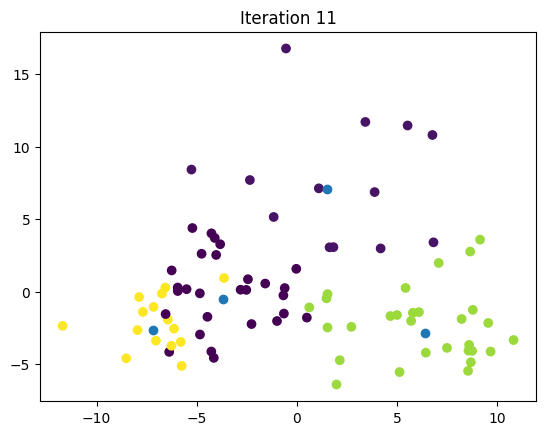

In [26]:
max_iterations = 100
k = 4

# preset nodes or cluster points
manual_indices = [14, 15, 31, 34]
k = len(manual_indices)

# pull data from prest nodes
centroids = data.loc[manual_indices].T

centroids.columns = manual_indices

old_centroids = pd.DataFrame()
iteration = 1

while iteration < max_iterations and not centroids.equals(old_centroids):
    old_centroids = centroids

    labels = get_labels(data, centroids)
    centroids = new_centroids(data, labels, k)
    plot_clusters(data, labels, centroids, iteration)
# in plot preset colors + label centroids
    iteration += 1

In [31]:
centroids

,14,15,31,34
FG,3.761543,6.390323,3.811896,2.964497
FGA,4.223374,7.764380,5.646580,2.638900
FG%,5.477556,4.450807,2.865692,7.940125
3P,1.608240,3.703347,7.435237,1.214630
3PA,1.658213,3.883849,7.264528,1.203569
3P%,2.507603,3.466793,4.103616,2.021931
2P,4.333490,6.129426,2.816515,3.728497
2PA,4.511417,6.765750,3.029844,3.247940
2P%,4.748905,4.114871,3.608024,7.515067
eFG%,5.127745,4.438925,3.853058,7.799259


In [32]:
# get indices of selected centroid
seed_indices = centroids.columns

seed_players = df_2026.loc[seed_indices, 'Player']
print(seed_players)

14    Deandre Ayton
15      Derik Queen
31         Jay Huff
34     Jericho Sims
Name: Player, dtype: str


In [33]:
df_2026['Cluster'] = labels
df_results = df_2026[['Player', 'Team', 'Cluster']].sort_values(by='Cluster')
#counts of players in randomized clusters
print("Cluster Sizes:")
print(df_results['Cluster'].value_counts())
# figure out how to bring the player name into the cluster group as well

Cluster Sizes:
Cluster
31    29
14    28
34    15
15    13
Name: count, dtype: int64


In [34]:
#average stats for cluster groups - gemini coded
cluster_summary = df_2026.groupby('Cluster')[features[1:]].mean()
print(cluster_summary)

               FGA       FG%        3P       3PA       3P%         2P  \
Cluster                                                                 
14       13.853571  0.579750  0.385714  1.189286  0.300500   7.664286   
15       22.876923  0.534077  1.476923  4.476923  0.319583  10.715385   
31       17.431034  0.463103  2.889655  8.296552  0.347207   5.186207   
34        9.866667  0.691000  0.166667  0.340000  0.323400   6.633333   

               2PA       2P%      eFG%        FT  ...        DRB        TRB  \
Cluster                                           ...                         
14       12.653571  0.602214  0.592643  3.403571  ...   9.953571  16.021429   
15       18.392308  0.580000  0.566077  7.153846  ...  11.761538  16.023077   
31        9.131034  0.567724  0.546069  3.255172  ...   8.327586  11.355172   
34        9.526667  0.697600  0.698933  2.846667  ...   9.446667  15.540000   

              AST       STL       BLK       TOV        PF        PTS  \
Cluster       

In [36]:
#printing all names in clusters to determine groups
#manual indices
seed_indices = [34,14,15,31]

#loop to print out all players in said cluster
for cluster_id in seed_indices:
    seed_name = df_2026.loc[cluster_id, 'Player']
    print(f"Cluster {cluster_id} (Player: {seed_name})")
    
    names = df_2026[df_2026['Cluster'] == cluster_id]['Player'].tolist()
    
    if names:
        print(", ".join(names))
    else:
        print("No players were assigned to this specific seed.")
    
    print("\n")

Cluster 34 (Player: Jericho Sims)
DeAndre Jordan, Dwight Powell, Goga Bitadze, Jakob Poeltl, Jaxson Hayes, Jericho Sims, Luke Kornet, Mitchell Robinson, Moussa DiabatÃ©, Neemias Queta, Oso Ighodaro, Robert Williams, Rudy Gobert, Ryan Kalkbrenner, Walker Kessler


Cluster 14 (Player: Deandre Ayton)
Adem Bona, Andre Drummond, Clint Capela, Collin Murray-Boyles, Daniel Gafford, Day'Ron Sharpe, Deandre Ayton, Donovan Clingan, Dylan Cardwell, Isaiah Hartenstein, Isaiah Jackson, Isaiah Stewart, Ivica Zubac, Jarrett Allen, Julian Reese, Jusuf NurkiÄ, Mark Williams, Marvin Bagley III, Maxime Raynaud, Moussa Cisse, Nic Claxton, Nick Richards, Paul Reed, Precious Achiuwa, Steven Adams, Yanic Konan NiederhÃ¤user, Yves Missi, Zach Edey


Cluster 15 (Player: Derik Queen)
Alex Sarr, Alperen ÅengÃ¼n, Bam Adebayo, Chet Holmgren, Derik Queen, Domantas Sabonis, Giannis Antetokounmpo, Jalen Duren, Joel Embiid, Jonas ValanÄiÅ«nas, Karl-Anthony Towns, Nikola JokiÄ, Victor Wembanyama


Cluster 31 (Playe